# Hot-Hand Fallacy in an AI Model

**The bias.** The hot-hand fallacy is the human belief that a player who has just made several shots is more likely to make the next one — that streaks predict success. Gilovich, Vallone & Tversky (1985) showed that, conditional on a player's base rate, shot outcomes are very close to independent. The streak signal humans *feel* is largely an illusion.

**Plan.** This notebook uses 2014-15 NBA shot logs and builds a streak feature `made_last_3` (makes in the previous 3 attempts of the same game). Two AI models are then trained:

1. **Outcome model** — predicts whether the next shot is *made* from the streak feature. The data does *not* support a hot hand, so this model correctly learns near-zero weight on the streak. The bias is not in the outcomes.
2. **Decision model** — predicts the *type* of shot taken (its distance) from the streak feature. This model **does** exhibit the hot-hand fallacy: it learns that hot shooters take harder shots, because the humans who took those shots *believed* they were hot. The bias is encoded in the human decisions captured by the dataset, and the AI inherits it.

## 1. Load and clean the data
Each row is one shot attempt (~128k total). Key columns:

- `fgm` — 1 if the shot was made, 0 if missed (the outcome).
- `shot_dist` — distance from the basket in feet (a proxy for shot difficulty).
- `close_def_dist` — distance to the closest defender in feet.
- `shot_clock` — seconds left on the shot clock.
- `period`, `shot_number` — when in the game it happened.

Rows are sorted by `(player, game, period, shot_number)` so that the streak feature in the next step looks at the player's *immediately preceding* shots in the same game.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split

DATA_URL = 'https://raw.githubusercontent.com/tanmaychk/EDA-NBA-shot_logs/master/shot_logs.csv'
df = pd.read_csv(DATA_URL)
df.columns = [c.lower() for c in df.columns]

df = df[['player_name', 'game_id', 'period', 'shot_number',
         'shot_dist', 'close_def_dist', 'shot_clock', 'fgm']].dropna()
df = df.sort_values(['player_name', 'game_id', 'period', 'shot_number']).reset_index(drop=True)

print(f'{len(df):,} shots, league FG% = {df.fgm.mean():.3f}')
df.head()

122,502 shots, league FG% = 0.456


,player_name,game_id,period,shot_number,shot_dist,close_def_dist,shot_clock,fgm
0,aaron brooks,21400010,1,1,5.7,0.9,14.4,1
1,aaron brooks,21400010,1,2,25.1,8.0,16.3,1
2,aaron brooks,21400010,2,3,6.7,2.3,18.1,1
3,aaron brooks,21400010,2,4,7.0,3.0,10.9,0
4,aaron brooks,21400010,2,5,1.6,5.2,11.5,1


## 2. Build the streak feature
`made_last_3` ∈ {0, 1, 2, 3} = makes in the player's previous 3 attempts in the same game. This is exactly the cue a hot-hand believer would use ("he just hit 3 in a row, give him the ball").

`shift(1)` is critical: it excludes the *current* shot from the rolling sum, so the feature only knows about prior shots. Without it, the label would leak into the feature.

In [7]:
def streak(s, k=3):
    return s.shift(1).rolling(k, min_periods=1).sum()

df['made_last_3'] = (df.groupby(['player_name', 'game_id'])['fgm']
                       .transform(lambda s: streak(s, 3)))
df = df.dropna(subset=['made_last_3'])
df['made_last_3'] = df['made_last_3'].astype(int)
df[['player_name', 'shot_number', 'fgm', 'made_last_3']].head(8)

,player_name,shot_number,fgm,made_last_3
1,aaron brooks,2,1,1
2,aaron brooks,3,1,2
3,aaron brooks,4,0,3
4,aaron brooks,5,1,2
6,aaron brooks,2,0,1
7,aaron brooks,4,1,1
8,aaron brooks,5,0,2
9,aaron brooks,6,1,1


## 3. Does the streak actually predict the next make?
Before training any model, the raw conditional means in the data are useful: for each value of `made_last_3`, what fraction of next shots were made?

If the hot hand were real, this column would rise sharply from streak 0 → streak 3. In practice it stays roughly flat (and slightly declines at the highest streak) — the empirical refutation of the hot-hand belief.

In [8]:
df.groupby('made_last_3')['fgm'].agg(['mean', 'count']).rename(
    columns={'mean': 'P(make next shot)', 'count': 'n_shots'})

,P(make next shot),n_shots
made_last_3,,
0,0.460345,23389
1,0.460213,45392
2,0.455843,31535
3,0.445845,8014


## 4. Outcome model — does the AI learn the (false) hot-hand belief?
A logistic regression is fit to predict `fgm` (made/missed) from the streak feature alone. If the model learned a meaningfully positive coefficient on `made_last_3`, it would have absorbed the hot-hand fallacy. Given the result in step 3, the coefficient should be very small — i.e., the AI trained on outcomes correctly rejects the human belief.

In [9]:
X = df[['made_last_3']].values
y = df['fgm'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)

outcome_model = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
print(f'Coefficient on made_last_3: {outcome_model.coef_[0, 0]:+.4f}')

# Predicted probability of a make for each streak value 0..3
probs = outcome_model.predict_proba(np.array([[0], [1], [2], [3]]))[:, 1]
pd.DataFrame({'made_last_3': [0, 1, 2, 3],
              'model P(make next shot)': probs.round(4)})

Coefficient on made_last_3: -0.0191


,made_last_3,model P(make next shot)
0,0,0.4635
1,1,0.4588
2,2,0.4541
3,3,0.4493


**Reading this table.** Each row says: "if a player made `k` of their last 3 shots, the model's predicted probability that the next shot is a make is …" The coefficient is essentially zero and the predicted probabilities are nearly flat across streak values — **the outcome model does not exhibit the hot-hand fallacy**, because the data does not support it.

So where is the bias? It is in the human *decisions*, not the outcomes. That is the next test.

## 5. Decision model — the bias lives in shot selection
Even though streaks don't predict makes, the *players, coaches, and defenders in the data behaved as if they did*. Hot shooters get the ball more, take longer-range shots, and draw tighter coverage — all driven by the (false) belief that they're hot. This shows up directly in the conditional averages of shot characteristics.

In [10]:
df.groupby('made_last_3')[['shot_dist', 'close_def_dist', 'shot_clock']].mean().round(2)

,shot_dist,close_def_dist,shot_clock
made_last_3,,,
0,13.18,4.13,12.70
1,13.32,4.11,12.50
2,13.52,4.08,12.31
3,13.72,4.12,12.27


A linear regression now predicts **shot distance** from the streak. If the coefficient on `made_last_3` is positive, the model has learned that hot shooters take longer shots — that is, it has absorbed the hot-hand fallacy as it shows up in human decision-making.

Coefficient on made_last_3: +0.179 feet per made shot
 made_last_3  model E[shot_dist] (ft)
           0                   13.159
           1                   13.337
           2                   13.516
           3                   13.695


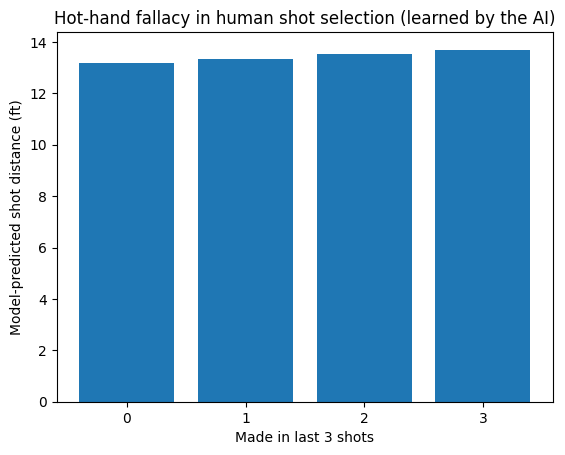

In [11]:
Xd = df[['made_last_3']].values
yd = df['shot_dist'].values

decision_model = LinearRegression().fit(Xd, yd)
print(f'Coefficient on made_last_3: {decision_model.coef_[0]:+.3f} feet per made shot')

# Predicted shot distance for each streak value 0..3
preds = decision_model.predict(np.array([[0], [1], [2], [3]]))
result = pd.DataFrame({'made_last_3': [0, 1, 2, 3],
                       'model E[shot_dist] (ft)': preds.round(3)})
print(result.to_string(index=False))

plt.bar(result['made_last_3'], result['model E[shot_dist] (ft)'])
plt.xticks([0, 1, 2, 3])
plt.xlabel('Made in last 3 shots')
plt.ylabel('Model-predicted shot distance (ft)')
plt.title('Hot-hand fallacy in human shot selection (learned by the AI)')
plt.show()

**Reading this chart.** Each bar is the model's expected shot distance given the streak value. Bars rising left-to-right mean the AI has learned: "the more shots a player just made, the farther out their next shot will be." That is the hot-hand fallacy reproduced by the AI — not because long-range shots after streaks are *more likely to go in* (step 4 showed they aren't), but because the humans whose decisions the model is fit on *believed* in the hot hand and acted on it.

## 6. Interpretation
- **Step 3 (raw data).** Conditional make-rates are roughly flat across streak length. The hot hand is not real in the outcomes.
- **Step 4 (outcome model).** A logistic regression on `made_last_3` learns a near-zero coefficient. The AI trained on outcomes correctly does **not** exhibit the bias.
- **Step 5 (decision model).** A linear regression on `made_last_3` predicting shot distance learns a positive coefficient. The AI trained on human decisions **does** exhibit the bias — it learned that hot shooters take harder shots, because the humans in the dataset acted on the hot-hand belief.

The lesson: a cognitive bias enters an AI system through the labels it is trained to predict. Outcomes (truth) refute the bias; human decisions (behavior) encode it. Any AI trained on human-generated decisions inherits the human's cognitive biases.